# The Tiger Game

The Tiger Game is a classic decision-making problem that resembles a game-show scenario. In this game, a decision maker faces two closed doors. Behind one door is a valuable prize (worth +10), while behind the other door lurks a dangerous tiger (worth -100 if encountered). The decision maker has three possible actions:

1. **Open Left Door (OL)**: Open the left door to claim what's behind it
2. **Open Right Door (OR)**: Open the right door to claim what's behind it  
3. **Listen (L)**: Listen for the tiger's growl to gain information about which door conceals the tiger (costs -1)

The challenge is that listening is imperfect - the decision maker's hearing has noise, with approximately 15% chance of false positives and false negatives. This means that even after listening, there remains uncertainty about the tiger's true location.

# Partially Observable Markov Decision Processes (POMDPs)

A **Partially Observable Markov Decision Process (POMDP)** is a mathematical framework for sequential decision-making under uncertainty where the agent cannot directly observe the true state of the environment. A POMDP for agent *i* is formally defined as:

$$\text{POMDP}_i = \langle S, A_i, T_i, \Omega_i, O_i, R_i \rangle$$

where:
- **S**: Set of possible states of the environment
- **A_i**: Set of actions the agent can execute
- **T_i: S × A_i × S → [0,1]**: Transition function describing how actions affect states
- **Ω_i**: Set of observations the agent can receive
- **O_i: S × A_i × Ω_i → [0,1]**: Observation function specifying probabilities of observations given actions and resulting states
- **R_i: S × A_i → ℝ**: Reward function representing the agent's preferences

Since the agent cannot directly observe the true state, it maintains a **belief state** - a probability distribution over possible states *S*. The belief is updated using Bayes' rule after each action and observation:

$$b_i^t(s^t) = \beta \cdot O_i(o_i^t, s^t, a_i^{t-1}) \sum_{s^{t-1} \in S} b_i^{t-1}(s^{t-1}) T_i(s^t, a_i^{t-1}, s^{t-1})$$

where β is a normalizing constant. The agent's goal is to find a policy that maximizes expected cumulative reward over time.

# Modeling the Tiger Game as a POMDP

The Tiger Game is a canonical example of a POMDP because the decision maker cannot directly observe which door hides the tiger. The POMDP formulation is:

**States (S)**: `{TigerLeft, TigerRight}` - indicating which door conceals the tiger

**Actions (A)**: `{Listen, OpenLeft, OpenRight}`

**Observations (Ω)**: `{GrowlLeft, GrowlRight}` - what the agent hears when listening

**Transition Function (T)**: 
- Opening either door resets the game (tiger randomly placed behind a new door)
- Listening does not change the state

**Observation Function (O)**:
- When listening, the agent hears a growl from the correct side with probability ~0.85
- With probability ~0.15, the agent hears a growl from the wrong side (observation noise)
- Opening doors provides no informative observations

**Reward Function (R)**:
- Opening the door with the prize: +10
- Opening the door with the tiger: -100
- Listening: -1

The agent begins with a **prior belief** (e.g., uniform: 50% chance tiger is behind each door) and must decide whether to gather more information by listening (incurring cost) or to act based on current beliefs. The value of listening comes from reducing uncertainty about the tiger's location before committing to opening a door.

In [2]:
from memo import memo, domain
import jax
import jax.numpy as np

In [13]:
from enum import IntEnum

class S(IntEnum):
    TigerLeft = 0;
    TigerRight = 1;

class A(IntEnum):
    Listen = 0;
    OpenLeft = 1;
    OpenRight = 2

class O(IntEnum):
    GrowlLeft = 0
    GrowlRight = 1

# Belief space, discretized into 50 possible belief states
# 1 = 100% confidence tiger is on right
# 0 = 100% confidence tiger is on left
B = np.linspace(0, 1, 50)  

@jax.jit
def get_belief(b, s):
    """
    Get probability of state s given belief b.
    """
    # Array: [P(TigerLeft), P(TigerRight)]
    belief_probs = np.array([1.0 - b, b])
    return belief_probs[s]

@jax.jit
def Tr(s, a, s_):
    """
    Transition function: P(s' | s, a)
    
    Args:
        s: Current state
        a: Action taken
        s_: Next state
    
    Returns:
        Probability of transitioning to s_ given s and a
    """
    # Transition probability matrix for each action
    # Rows: current state, Cols: next state

    # Listen: state doesn't change (identity matrix)
    listen_trans = np.array([
        [1.0, 0.0],  # TigerLeft stays TigerLeft
        [0.0, 1.0]   # TigerRight stays TigerRight
    ])

    # Opening doors: game resets, tiger randomly placed (uniform)
    open_trans = np.array([
        [0.5, 0.5],  # From any state to 50/50
        [0.5, 0.5]
    ])

    # Stack into 3D array: [action, current_state, next_state]
    trans_matrix = np.stack([
        listen_trans,  # Action 0: Listen
        open_trans,    # Action 1: OpenLeft
        open_trans     # Action 2: OpenRight
    ])

    return trans_matrix[a, s, s_]

@jax.jit
def Obs(o, s, a):
    """
    Observation function: P(o | s, a)
    
    Args:
        o: Observation (0=GrowlLeft, 1=GrowlRight)
        s: Resulting state (States.TigerLeft or States.TigerRight)
        a: Action taken (Actions.Listen, OpenLeft, or OpenRight)
    
    Returns:
        Probability of observation o given state s and action a
    """
    # Observation probabilities for Listen action
    # Rows: states [TigerLeft, TigerRight]
    # Cols: observations [GrowlLeft, GrowlRight]
    listen_obs = np.array([
        [0.85, 0.15],  # TigerLeft: hear left w/ 0.85, right w/ 0.15
        [0.15, 0.85]   # TigerRight: hear left w/ 0.15, right w/ 0.85
    ])

    # For opening doors, observations are uninformative (uniform)
    open_obs = np.array([
        [0.5, 0.5],    # Opening doors gives no information
        [0.5, 0.5]
    ])

    # Stack into 3D array: [action, state, observation]
    obs_matrix = np.stack([
        listen_obs,    # Action 0: Listen
        open_obs,      # Action 1: OpenLeft
        open_obs       # Action 2: OpenRight
    ])

    return obs_matrix[a, s, o]

@jax.jit
def R(s, a):
    """
    Reward function using JAX-compatible array indexing.
    
    Rewards:
    - Listen: -1
    - OpenLeft when TigerLeft: -100
    - OpenLeft when TigerRight: +10
    - OpenRight when TigerLeft: +10
    - OpenRight when TigerRight: -100
    """
    # Create a 2D reward matrix: rows=states, cols=actions
    # Columns: [Listen, OpenLeft, OpenRight]
    # Rows: [TigerLeft, TigerRight]
    reward_matrix = np.array([
        [-1.0, -100.0,   10.0],  # TigerLeft state
        [-1.0,   10.0, -100.0]   # TigerRight state
    ])

    return reward_matrix[s, a]


In [14]:
from functools import cache

@memo(cache=True)
def Q[b: B, a: A](t):
    agent: knows(b, a)
    agent: thinks[
        env: knows(b, a),
        env: chooses(s in S, wpp=get_belief(b, s)),
        env: chooses(s_ in S, wpp=Tr(s, a, s_)),
        env: chooses(o in O, wpp=Obs(o, s_, a))
    ]
    agent: snapshots_self_as(future_agent)
    return agent[ E[R(env.s, a)] + (0.0 if t <= 0 else 0.95 * imagine[
        future_agent: observes[env.o] is env.o,
        future_agent: chooses(b_ in B, wpp=exp(-100.0 * abs(E[env.s_] - b_))),
        future_agent: chooses(a_ in A, to_maximize=Q[b_, a_](t - 1)),
        E[ future_agent[ Q[b_, a_](t - 1) ] ]
    ]) ]

%timeit -r 10 -n 10 Q.cache_clear(); Q(100).block_until_ready()

26 ms ± 5.73 ms per loop (mean ± std. dev. of 10 runs, 10 loops each)


In [15]:
# Run the solver
q = Q(10)
v = np.max(q, axis=1, keepdims=True)
p = (q == v) * 1.0
v = v.squeeze(-1)

# Print some basic information
print("Q-values shape:", q.shape)
print("\nValue function (max Q) for some belief states:")
for i in [0, 12, 24, 37, 49]:
    print(f"  b={B[i]:.2f} (P(TigerRight)={B[i]:.0%}): V={v[i]:.2f}")

# Print optimal policy for key belief states
action_names = ['Listen', 'OpenLeft', 'OpenRight']
print("\nOptimal policy:")
for i in [0, 12, 24, 37, 49]:
    optimal_actions = [action_names[a] for a in range(3) if p[i, a] == 1.0]
    print(f"  b={B[i]:.2f}: {', '.join(optimal_actions)}")


Q-values shape: (50, 3)

Value function (max Q) for some belief states:
  b=0.00 (P(TigerRight)=0%): V=16.62
  b=0.24 (P(TigerRight)=24%): V=8.36
  b=0.49 (P(TigerRight)=49%): V=7.57
  b=0.76 (P(TigerRight)=76%): V=8.36
  b=1.00 (P(TigerRight)=100%): V=16.62

Optimal policy:
  b=0.00: OpenRight
  b=0.24: Listen
  b=0.49: Listen
  b=0.76: Listen
  b=1.00: OpenLeft


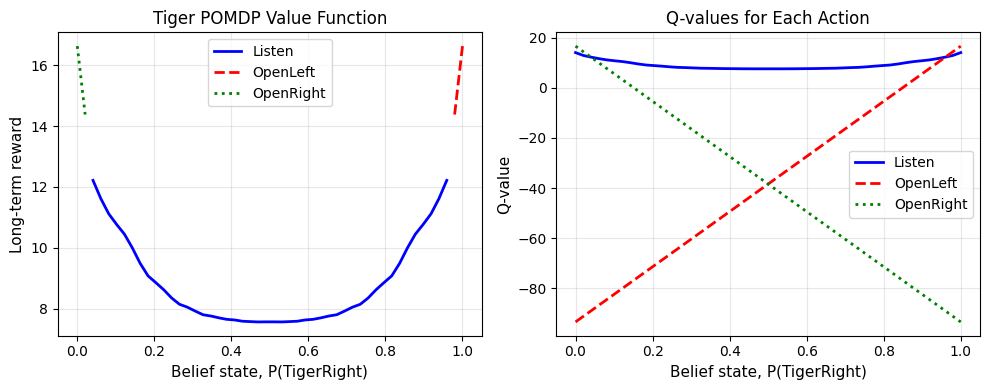

In [16]:
# Make a visualization of the value function and policy
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 4))

# Plot 1: Value function and policy regions
plt.subplot(1, 2, 1)
plt.plot(B[p[:, 0] == 1], v[p[:, 0] == 1], 'b-', label='Listen', linewidth=2)
plt.plot(B[p[:, 1] == 1], v[p[:, 1] == 1], 'r--', label='OpenLeft', linewidth=2)
plt.plot(B[p[:, 2] == 1], v[p[:, 2] == 1], 'g:', label='OpenRight', linewidth=2)
plt.xlabel('Belief state, P(TigerRight)', fontsize=11)
plt.ylabel('Long-term reward', fontsize=11)
plt.title('Tiger POMDP Value Function', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Q-values for all actions
plt.subplot(1, 2, 2)
plt.plot(B, q[:, 0], 'b-', label='Listen', linewidth=2)
plt.plot(B, q[:, 1], 'r--', label='OpenLeft', linewidth=2)
plt.plot(B, q[:, 2], 'g:', label='OpenRight', linewidth=2)
plt.xlabel('Belief state, P(TigerRight)', fontsize=11)
plt.ylabel('Q-value', fontsize=11)
plt.title('Q-values for Each Action', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
